<a href="https://colab.research.google.com/github/gitmystuff/DTSC5502/blob/main/Project/Make_Me_Data_Science_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Make Me Data Science II

Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5502 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name
* Clean up Colab Notebooks folder
* Submit shared link

## Objectives

See Table of Contents

A Data Scientist’s roles and responsibilities include extracting data from multiple sources, using machine learning tools to organize data, process, clean, and validate the data, analyze the data for information and patterns, develop prediction systems, present the data in a clear manner, and propose solutions and strategies.

https://www.simplilearn.com/data-scientist-job-description-article#:~:text=A%20Data%20Scientist's%20roles%20and,manner%2C%20and%20propose%20solutions%20and

Data cleaning is essential in preparing data for analysis, and it is important to handle potential data errors before presenting results. Comparing model results with and without the data errors allows presentation of graphical evidence to show that data cleaning is worth the time spent.

https://chance.amstat.org/2020/02/data-cleaning/#:~:text=Data%20cleaning%20is%20essential%20in,is%20worth%20the%20time%20spent.

In [ ]:
# ! git clone https://github.com/gitmystuff/preppy.git

In [ ]:
# import shutil

# # Source file path (within your Drive)
# source_file = '/content/drive/MyDrive/DTSC5502/Project CICD/preppy report.py'

# # Destination path (root of your Drive)
# destination_path = '/content/preppy/utils/report.py'

# # Copy the file
# shutil.copy(source_file, destination_path)

## Outline

* Set the Stage
* Create the Data
* Data Prep
* Exploratory Data Analysis
* Feature Engineering
* Feature Selection
* Data Modeling
* Model Evaluation
* Model Fine-Tuning
* Model Deployment

## Create the Data

In [ ]:
pip install Faker

In [ ]:
state_names=["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]

In [ ]:
# create demographic data
import numpy as np
import pandas as pd
from faker import Faker
fake = Faker()

output = []
for x in range(1000):
  binary = np.random.choice(['binary_1', 'binary_2'], p=[0.5, 0.5])
  output.append({
        'binary': binary, # sex assigned at birth
        'given_name': fake.first_name_female() if binary=='binary_1' else fake.first_name_male(),
        'surname': fake.last_name(),
        'date_of_birth': fake.date_of_birth(),
        'phone_number': fake.phone_number(),
        'email': fake.email(),
        'address': fake.address(),
        'city': fake.city(),
        'state': np.random.choice(state_names),
        'zipcode': fake.zipcode(),
        })

demographics = pd.DataFrame(output)
demographics.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode
0,binary_1,Lindsey,Nichols,1947-05-31,+1-954-202-3357,robert20@example.net,"64495 Kathy Camp\nPatriciatown, PR 86774",Port Johnport,Massachusetts,33819
1,binary_1,Mary,Anderson,1939-07-15,(891)806-1140x8445,ycase@example.org,"95492 Daniel Row Suite 322\nLindaside, NV 79590",Phillipbury,Montana,72223
2,binary_2,Bradley,Spencer,1953-02-12,445-278-8979,hunterreyes@example.com,"758 Johnny Shoal\nBergfort, NC 23106",Lucasfurt,Arkansas,36907
3,binary_2,Dennis,Sawyer,1964-07-03,001-870-398-6051x6189,snowjustin@example.com,33944 Angelica Dale Apt. 988\nLake Zacharymout...,West Luismouth,Nebraska,68345
4,binary_1,Jessica,Navarro,2024-09-27,(452)408-4334x811,xbanks@example.net,"66872 Amanda Springs Apt. 767\nPort Zachary, M...",Martineztown,Florida,80725


In [ ]:
# create a base dataframe with 1 dependent variable and 2 features, both informative
from sklearn.datasets import make_regression, make_classification

X, y = make_regression(n_samples=1000, n_features=2, n_informative=2, noise=0.1, random_state=42)
df = pd.DataFrame(X, columns=['informative_1', 'informative_2'])
df = pd.concat([demographics, df], axis=1).reset_index(drop=True)
df['target'] = y
df.head()

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,informative_1,informative_2,target
0,binary_1,Lindsey,Nichols,1947-05-31,+1-954-202-3357,robert20@example.net,"64495 Kathy Camp\nPatriciatown, PR 86774",Port Johnport,Massachusetts,33819,-0.167118,0.146714,-5.926650
1,binary_1,Mary,Anderson,1939-07-15,(891)806-1140x8445,ycase@example.org,"95492 Daniel Row Suite 322\nLindaside, NV 79590",Phillipbury,Montana,72223,-0.020902,0.117327,-0.202458
2,binary_2,Bradley,Spencer,1953-02-12,445-278-8979,hunterreyes@example.com,"758 Johnny Shoal\nBergfort, NC 23106",Lucasfurt,Arkansas,36907,0.150419,0.364961,8.625180
3,binary_2,Dennis,Sawyer,1964-07-03,001-870-398-6051x6189,snowjustin@example.com,33944 Angelica Dale Apt. 988\nLake Zacharymout...,West Luismouth,Nebraska,68345,0.555604,0.089581,23.044850
4,binary_1,Jessica,Navarro,2024-09-27,(452)408-4334x811,xbanks@example.net,"66872 Amanda Springs Apt. 767\nPort Zachary, M...",Martineztown,Florida,80725,0.058209,-1.142970,-5.265220


## Automation Functions

1. gen_null(series, perc)
2. gen_quasi_constants(primary_label, variation_percentage=.2, replace=False)
3. gen_normal_data(mu=0, std=1, size=len(df))
4. gen_uniform_data(size=len(df))
5. gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
6. gen_correlated_normal_series(original_series, target_correlation, size=len(df))
7. gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
8. gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
9. gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000)
10. gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10)
11. random_choice_data(choices, size)

In [ ]:
# functions
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


def gen_null(series, perc):
  """
  Introduces null values (np.nan) into a list based on a specified percentage.

  Args:
      var: The variable to modify.
      perc: The percentage of values to replace with nulls (0-100).

  Returns:
      The modified variable with null.
  """
  var = series.copy()
  num_nulls = int(len(var) * (perc / 100))
  indices_to_replace = np.random.choice(len(var), num_nulls, replace=False)

  for idx in indices_to_replace:
      var[idx] = np.nan

  return var

def gen_quasi_constants(primary_label, variation_percentage=.2, size=len(df)):
  """
  Generates quasi-constant labels for a Series, with a small percentage of variation.

  Args:
      primary_label: The main label to use for most values.
      variation_percentage: The percentage of labels to vary (0-100).

  Returns:
      A new Series containing the quasi-constant labels.
  """

  series = pd.Series(np.full(size, primary_label))
  num_variations = int(size * (variation_percentage / 100))
  variation_indices = np.random.choice(series.index, num_variations, replace=False)
  primary_label = primary_label + '_0'
  variation1 = primary_label + '_1'
  variation2 = primary_label + '_2'

  labels = pd.Series([primary_label] * len(series), index=series.index)
  labels.loc[variation_indices] = np.random.choice([variation1, variation2], size=num_variations)  # Adjust variations as needed

  return labels

def gen_normal_data(mu=0, std=1, size=len(df)):
  """
  Generates a normal dataset given the mean and standard deviation

  Args:
        mu: The mean of the normal distribution.
        std: The standard deviation of the normal distribution.
        size: The number of data points to generate.

  Returns:
        A normally distributed series.
  """
  return np.random.normal(mu, std, size)

def gen_uniform_data(size=len(df)):
  """
  Generates a uniform dataset

  Args:
        size: The number of data points to generate.

  Returns:
        A uniform distributed series.
  """
  return np.random.uniform(size=size)

def gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df)):
  """
  Generates two datasets with a multivariate normal distribution given the mean and covariance matrix

  Args:
        mean: The mean of each of the datasets.
        cov: The covariance matrix of the datasets.
        size: The number of data points to generate.

  Returns:
        Two correlated series.
  """
  ds1, ds2 = np.random.multivariate_normal(mean, cov, size, tol=1e-6).T # ds = dataset
  return ds1, ds2

def gen_correlated_normal_series(original_series, target_correlation, size=len(df)):
  """
  Generates a correlated series based on a given series.

  This function takes an original series as input and generates a new series
  that is correlated with the original series. The correlation between the
  original and generated series is approximately equal to the specified
  target correlation.

  The generated series is created by linearly transforming the original series
  and adding Gaussian noise with an adjusted standard deviation to achieve the
  desired correlation.

  Args:
      original_series (numpy.ndarray): The original series.
      target_correlation (float): The desired Pearson correlation coefficient
          between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series.
  """
  return np.mean(original_series) + target_correlation * (original_series - np.mean(original_series)) \
  +  np.random.normal(0, np.sqrt(1 - target_correlation**2) * np.std(original_series), len(original_series))
  """
  Explanation

  This one-liner leverages the properties of linear transformations and normal distributions to generate a correlated series.

  It first centers the original_series by subtracting its mean.
  It then scales this centered series by the target_correlation.
  Finally, it adds Gaussian noise with a standard deviation adjusted to ensure the overall correlation matches the target_correlation.
  """

def gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df)):
  """
  Work in progress

  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.
      size: The number of data points to generate.

  Returns:
      The generated correlated series with a uniform distribution.
  """
  z_scores = (original_series - np.mean(original_series)) / np.std(original_series)
  correlation_coefficient=.7
  return norm.cdf(correlation_coefficient * norm.ppf(np.random.uniform(size=size)) + np.sqrt(1 - correlation_coefficient**2) * z_scores)

def pearson_r_func(x, y, y_mean, y_std, desired_r):
    x_mean = np.mean(x)
    x_std = np.std(x)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = x_std * y_std * len(x)
    calculated_r = numerator / denominator
    return (calculated_r - desired_r)**2  # Minimize the squared difference

def minimize_r(original_series, target_correlation, size=len(df)):
    y = original_series
    y_mean = np.mean(y)
    y_std = np.std(y)
    desired_r = target_correlation

    # Initial guess for x values
    x0 = np.random.uniform(size=len(original_series))

    # Solve for x
    result = minimize(pearson_r_func, x0, args=(y, y_mean, y_std, desired_r))

    if result.success:
        x_solution = result.x
        # print("Solution for x:", x_solution)
        return x_solution
    else:
        print("Optimization failed.")

def gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3):
    """
    Generates a normal distribution with outliers.

    Args:
        mean (float): The mean of the normal distribution.
        std_dev (float): The standard deviation of the normal distribution.
        size (int): The number of samples to generate.
        outlier_percentage (float): The percentage of outliers to introduce (between 0 and 1).
        outlier_magnitude (float): The magnitude by which outliers deviate from the mean.

    Returns:
        numpy.ndarray: The generated data with outliers.
    """
    data = np.random.normal(mean, std_dev, size)
    num_outliers = int(size * outlier_percentage)
    outlier_indices = np.random.choice(size, num_outliers, replace=False)
    for index in outlier_indices:
        if np.random.rand() < 0.5:
            data[index] += outlier_magnitude
        else:
            data[index] -= outlier_magnitude

    return data

def gen_standard_scaling(mean=50, std_dev=10, size=len(df), scale_factor=1000):
  """
  Generates data with a specified mean and standard deviation, then scales it by a factor to create a distribution needing scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      scale_factor (float): The factor by which to scale the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """
  original_data = np.random.normal(mean, std_dev, size)
  return original_data * scale_factor

def gen_minmax_scaling(mean=50, std_dev=10, size=len(df), range_factor=10):
  """
  Generates data with a specified mean and standard deviation, then scales and shifts it to create a distribution needing MinMax scaling.

  Args:
      mean (float): The mean of the original distribution.
      std_dev (float): The standard deviation of the original distribution.
      size (int): The number of samples to generate.
      range_factor (float): The factor to expand the range of the original distribution.

  Returns:
      numpy.ndarray: The generated data needing scaling.
  """

  # Generate the original data
  original_data = np.random.normal(mean, std_dev, size)

  # Expand the range of the data
  min_val = np.min(original_data)
  max_val = np.max(original_data)
  return (original_data - min_val) * range_factor + min_val

def random_choice_data(choices, size):
  """
  Generates a new series correlated with the given series based on the specified correlation coefficient,
  using rank correlation to ensure the generated series follows a uniform distribution.

  Args:
      original_series (numpy.ndarray or list): The original series.
      correlation_coefficient (float): The desired correlation coefficient between the original and generated series.

  Returns:
      numpy.ndarray: The generated correlated series with a uniform distribution.
  """
  return np.random.choice(choices, size=size)


In [ ]:
# categorical variables with little correlation to sales
df['random choice 2'] = random_choice_data(['Rand Choice 1', 'Rand Choice 2'], size=len(df))
df['random choice 4'] = random_choice_data(['North', 'South', 'East', 'West'], size=len(df))
df['random choice 7'] = random_choice_data(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], size=len(df))

# categorical random choices with random # of labels
num_labels = np.random.randint(3, 5)
df[f'random label num {num_labels}'] = random_choice_data([f'label num lo {i}' for i in range(1, num_labels + 1)], size=len(df))

num_labels = np.random.randint(10, 15)
df[f'random label num {num_labels}'] = random_choice_data([f'label num hi {i}' for i in range(1, num_labels + 1)], size=len(df))

In [ ]:
# categorical variables correlated with target
df['pd qcut1'] = pd.qcut(df['target'], 2, labels=['Low', 'High']) # bi label
df['pd qcut2'] = pd.qcut(df['target'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']) # 4 labels

quantiles = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1]
df['pd qcut3'] = pd.qcut(df['target'], quantiles, labels=['G1', 'G2', 'G3', 'G4', 'G5', 'G6']) # 6 labels

In [ ]:
# generate four numerical normally distributed continuous features that have a correlation greater than absolute value of .5 with each other
# gen_multivariate_normal_data(mean=[0, 0], cov=[[1, 0], [0, 1]], size=len(df))
df['multicollinearity 1'], df['multicollinearity 2'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .7], [.7, 1]], size=len(df))
df['multicollinearity 3'], df['multicollinearity 4'] = gen_multivariate_normal_data(mean=[0, 0], cov=[[1, .9], [.9, 1]], size=len(df))

In [ ]:
# generate two normally distributed features that are correlated with the target
# gen_correlated_normal_series(original_series, target_correlation, size=len(df))
df['correlated w target 1'] = gen_correlated_normal_series(df['target'], target_correlation=.5)
df['correlated w target 2'] = gen_correlated_normal_series(df['target'], target_correlation=.7)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 1000 non-null   object  
 1   given_name             1000 non-null   object  
 2   surname                1000 non-null   object  
 3   date_of_birth          1000 non-null   object  
 4   phone_number           1000 non-null   object  
 5   email                  1000 non-null   object  
 6   address                1000 non-null   object  
 7   city                   1000 non-null   object  
 8   state                  1000 non-null   object  
 9   zipcode                1000 non-null   object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  random choice 2        1000 non-null   object  
 14  random choice 4        1000 non-null   ob

                uniform corr 1  uniform corr 2    target
uniform corr 1        1.000000        0.492620  0.696481
uniform corr 2        0.492620        1.000000  0.715683
target                0.696481        0.715683  1.000000


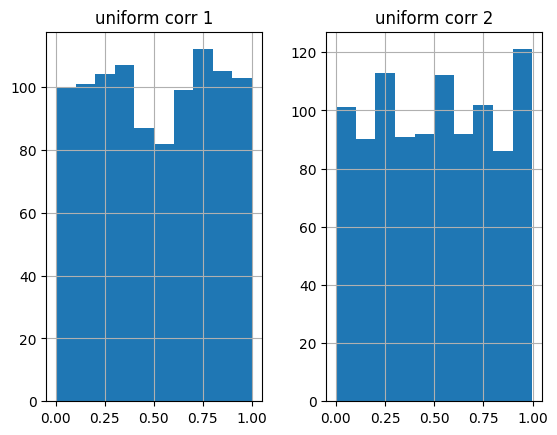

In [ ]:
# generate two uniformly distributed features that are correlated with the target
# gen_correlated_uniform_series(original_series, correlation_coefficient=0, size=len(df))
df['uniform corr 1'] = gen_correlated_uniform_series(df['target'])
df['uniform corr 2'] = gen_correlated_uniform_series(df['target'])

print(df[['uniform corr 1', 'uniform corr 2', 'target']].corr())
df[['uniform corr 1', 'uniform corr 2']].hist();

In [ ]:
# create two features that are duplicates of other features
df['duplicate_1'] = df['informative_1']
df['duplicate_2'] = df['informative_2']

In [ ]:
# create two numerical features with outliers
df['outliers 1'] = gen_outliers(mean=0, std_dev=1, size=len(df), outlier_percentage=0.1, outlier_magnitude=3)
df['outliers 2'] = gen_outliers(mean=3, std_dev=2, size=len(df), outlier_percentage=0.2, outlier_magnitude=2)

In [ ]:
# create a numerical feature that needs standard scaling
df['standard scaling'] = gen_standard_scaling()

In [ ]:
# create a numerical feature that needs min max scaling
df['min max scaling'] = gen_minmax_scaling()

In [ ]:
# generate null values
for col in df.drop(['informative_1', 'informative_2', 'target'], axis=1).columns:
    df[col] = gen_null(df[col], np.random.choice([0, 5, 10, 20, 30, 50], size=1).item())

In [ ]:
# create two features that have constant values
df['constant_1'] = 'constant_value'
df['constant_2'] = 'constant_value'

In [ ]:
# create two features with semi constant values
df['semi_constant_1'] = gen_quasi_constants('q_const', variation_percentage = 1)
df['semi_constant_2'] = gen_quasi_constants('q_const', variation_percentage = 1)

In [ ]:
print(df.info())  # check your work

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 900 non-null    object  
 1   given_name             700 non-null    object  
 2   surname                800 non-null    object  
 3   date_of_birth          500 non-null    object  
 4   phone_number           700 non-null    object  
 5   email                  1000 non-null   object  
 6   address                1000 non-null   object  
 7   city                   1000 non-null   object  
 8   state                  950 non-null    object  
 9   zipcode                1000 non-null   object  
 10  informative_1          1000 non-null   float64 
 11  informative_2          1000 non-null   float64 
 12  target                 1000 non-null   float64 
 13  random choice 2        500 non-null    object  
 14  random choice 4        950 non-null    ob

In [ ]:
# add duplicates
dupes = df.loc[0:9]
df = pd.concat([df, dupes], axis=0)

# shuffle all columns
# df = df.sample(frac=1).reset_index(drop=True)
# df = df.sample(frac=1, axis=1)

# shuffle selected columns
demographic_columns = demographics.columns
remaining_columns = [col for col in df.columns if col not in demographic_columns]
# print(remaining_columns)
np.random.shuffle(remaining_columns)

# Reassemble the DataFrame with the shuffled columns
df = df[list(demographic_columns) + list(remaining_columns)]

# move target to the end of the list
target = 'target'
df = df[df.drop('target', axis=1).columns.tolist() + [target]]

print(df.shape)
print(df.info())
df.head()

(1010, 39)
<class 'pandas.core.frame.DataFrame'>
Index: 1010 entries, 0 to 9
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   binary                 908 non-null    object  
 1   given_name             706 non-null    object  
 2   surname                805 non-null    object  
 3   date_of_birth          506 non-null    object  
 4   phone_number           707 non-null    object  
 5   email                  1010 non-null   object  
 6   address                1010 non-null   object  
 7   city                   1010 non-null   object  
 8   state                  960 non-null    object  
 9   zipcode                1010 non-null   object  
 10  multicollinearity 4    910 non-null    float64 
 11  multicollinearity 2    709 non-null    float64 
 12  uniform corr 2         706 non-null    float64 
 13  duplicate_2            960 non-null    float64 
 14  semi_constant_1        1010 non-null 

,binary,given_name,surname,date_of_birth,phone_number,email,address,city,state,zipcode,...,pd qcut2,uniform corr 1,semi_constant_2,pd qcut3,min max scaling,random choice 7,informative_2,random choice 2,random choice 4,target
0,binary_1,Lindsey,Nichols,1947-05-31,+1-954-202-3357,robert20@example.net,"64495 Kathy Camp\nPatriciatown, PR 86774",Port Johnport,Massachusetts,33819,...,Q2,0.411809,q_const_0,NaN,NaN,Sunday,0.146714,Rand Choice 1,East,-5.926650
1,binary_1,Mary,NaN,1939-07-15,(891)806-1140x8445,ycase@example.org,"95492 Daniel Row Suite 322\nLindaside, NV 79590",Phillipbury,Montana,72223,...,Q2,0.469403,q_const_0,G4,NaN,Tuesday,0.117327,NaN,West,-0.202458
2,NaN,Bradley,NaN,NaN,NaN,hunterreyes@example.com,"758 Johnny Shoal\nBergfort, NC 23106",Lucasfurt,Arkansas,36907,...,NaN,NaN,q_const_0,G4,341.264752,Tuesday,0.364961,Rand Choice 1,North,8.625180
3,binary_2,NaN,NaN,1964-07-03,001-870-398-6051x6189,snowjustin@example.com,33944 Angelica Dale Apt. 988\nLake Zacharymout...,West Luismouth,Nebraska,68345,...,Q3,0.219235,q_const_0,G5,NaN,Monday,0.089581,NaN,East,23.044850
4,binary_1,NaN,Navarro,NaN,NaN,xbanks@example.net,"66872 Amanda Springs Apt. 767\nPort Zachary, M...",Martineztown,Florida,80725,...,Q2,0.366466,q_const_0,G4,417.814003,Saturday,-1.142970,NaN,North,-5.265220


## Exploratory Data Analysis

Exploratory data analysis (EDA) is a data analysis method that helps data scientists understand their data and identify patterns. It's often used as the first step in data analysis.

## Correlation

In [ ]:
# code along

In [ ]:
# # show correlation between the features
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # correlation matrix
# sns.set(style="white")

# # compute the correlation matrix
# corr = df._get_numeric_data().corr().round(2)

# # generate a mask for the upper triangle
# mask = np.zeros_like(corr, dtype=bool)
# mask[np.triu_indices_from(mask)] = True

# # set up the matplotlib figure
# # f, ax = plt.subplots()
# f = plt.figure(figsize=(12, 12))

# # generate a custom diverging colormap
# cmap = sns.diverging_palette(220, 10, as_cmap=True)

# # draw the heatmap with the mask and correct aspect ratio
# sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
#             square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True);

# plt.tight_layout()

In [ ]:
# # calculate the correlation matrix
# corr_matrix = df._get_numeric_data().corr()

# # Create a mask for the upper triangle (to avoid duplicates)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# # Convert the correlation matrix to a long format
# corr_df = corr_matrix.stack().reset_index()
# corr_df.columns = ['feature1', 'feature2', 'correlation']

# # Filter for correlations above a certain threshold (e.g., 0.7)
# high_corr_df = corr_df[(abs(corr_df['correlation']) > 0.7) & (corr_df['feature1'] != corr_df['feature2'])]

# # Sort by absolute correlation in descending order
# high_corr_df = high_corr_df.sort_values(by='correlation', ascending=False, key=abs)

# # Print the top correlated features
# # print(high_corr_df['feature1'].to_list()[4:10])
# print(high_corr_df)

In [ ]:
# # check for vif
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # handle null values (using mean imputation for simplicity)
# x_copy = df.drop('target', axis=1)._get_numeric_data()
# x_copy.fillna(x_copy.mean(), inplace=True)

# print(max([variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]))

# # calculate VIF
# vif = pd.DataFrame()
# vif["Variable"] = x_copy.columns
# vif["VIF"] = [variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]
# print(vif)

## Multicollinearity

* We want high correlation with target
* We don't want high correlation between features
* Drop correlated features
* Combine correlated features

In [ ]:
# # create a new variable by combining two variables
# df['scaling_combined'] = df['standard scaling'] + df['min max scaling']
# df.drop(['standard scaling', 'min max scaling'], axis=1, inplace=True)

In [ ]:
# # iterate dropping features with high vif
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# removed1=[]
# x_copy1 = x_copy.copy()
# max_vif = thresh = 10
# while max_vif >= thresh:
#   my_list = [variance_inflation_factor(x_copy1, i) for i in range(x_copy1.shape[1])]
#   max_vif = max(my_list)
#   if max_vif > thresh:
#     max_index = my_list.index(max_vif)
#     removed1.append(x_copy1.columns[max_index])
#     print(x_copy1.columns[max_index], variance_inflation_factor(x_copy1, max_index))
#     x_copy1.drop(x_copy1.columns[max_index], axis=1, inplace=True)


# # Calculate VIF
# vif = pd.DataFrame()
# vif["Variable"] = x_copy1.columns
# vif["VIF"] = [variance_inflation_factor(x_copy1, i) for i in range(x_copy1.shape[1])]
# print(vif)

In [ ]:
# # check again vif
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# removed2=[]
# max_vif = thresh = 10
# while max_vif >= thresh:
#   max_vif = max([variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])])
#   for i in range(x_copy.shape[1]):
#     if variance_inflation_factor(x_copy, i) > thresh:
#       removed2.append(x_copy.columns[i])
#       print(x_copy.columns[i], variance_inflation_factor(x_copy, i))
#       x_copy.drop(x_copy.columns[i], axis=1, inplace=True)
#       break

# # Calculate VIF
# vif = pd.DataFrame()
# vif["Variable"] = x_copy.columns
# vif["VIF"] = [variance_inflation_factor(x_copy, i) for i in range(x_copy.shape[1])]
# print(vif)

In [ ]:
# print(removed1)
# print(removed2)

## Outliers

In [ ]:
# code along

In [ ]:
# code along

In [ ]:
# code along

## Data Prep

https://www.udemy.com/course/feature-engineering-for-machine-learning

* Types and characteristics of data
* Missing data imputation
* Categorical encoding
* Variable transformation
* Discretization
* Outliers
* Datetime
* Scaling
* Feature creation

In [ ]:
# ! git clone https://github.com/gitmystuff/preppy.git

In [ ]:
# import shutil

# # Source file path (within your Drive)
# source_file = '/content/drive/MyDrive/DTSC5502/Project CICD/preppy report.py'

# # Destination path (root of your Drive)
# destination_path = '/content/preppy/utils/report.py'

# # Copy the file
# shutil.copy(source_file, destination_path)

In [ ]:
# import preppy.utils as utils
# import preppy.utils as utils
# from preppy.version import __version__

# print(__version__)

# utils.report.write_report(df, thresh=.8)

## Feature Engineering

In [ ]:
# df_numerical = df.select_dtypes(include='number').columns
# df_object = df.select_dtypes(include=['object']).columns
# df_discreet = df.select_dtypes(include=['category']).columns
# df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
# df_discreet

In [ ]:
# def handle_missing_values(df):
#   df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
#   dfx = df.copy()
#   for feat in df.columns[df.isnull().sum() > 1]:
#     if feat in df_categorical_features:
#       dfx[feat] = df[feat].fillna(df[feat].mode()[0])
#     else:
#       if abs(df[feat].skew()) < .8:
#         dfx[feat] = df[feat].fillna(round(df[feat].mean(), 2))
#       else:
#         dfx[feat] = df[feat].fillna(df[feat].median())

#   return dfx

# df = handle_missing_values(df)
# df.info()

## Pipelines

## BaseEstimator, TransformerMixin

Imagine you're building a machine to process and transform data. `BaseEstimator` and `TransformerMixin` are like instruction manuals that help your machine understand how to work with different parts of the data.

**`BaseEstimator`**

*   Provides basic tools:** This is like a toolbox with essential tools for your machine. It provides methods for getting and setting parameters (like knobs and switches on your machine) and for cloning the machine (making a copy of it).

**`TransformerMixin`**

*   Handles transformations:** This manual teaches your machine how to transform data. It provides a method called `fit_transform` that combines two steps:
    *   **`fit`:**  The machine learns something about the data (like figuring out the average value).
    *   **`transform`:** The machine uses what it learned to change the data (like subtracting the average value from each data point).

**Why use them with pipeline transformers?**

*   **Compatibility:** When you build custom transformers (special parts for your machine) and want to use them in a scikit-learn pipeline (a series of connected machines), inheriting from `BaseEstimator` and `TransformerMixin` ensures that your custom parts fit seamlessly with the other machines in the pipeline.
*   **Convenience:** `TransformerMixin` provides the handy `fit_transform` method, which streamlines the process of fitting and transforming data in one step.

**In simple terms**

`BaseEstimator` and `TransformerMixin` are like blueprints that help you build standardized and compatible parts for your data processing machine (pipeline), making it easier to manage and transform your data.

In [ ]:
# from sklearn.base import BaseEstimator, TransformerMixin
# import inspect

# print(dir(BaseEstimator))
# print(dir(TransformerMixin))

# print(BaseEstimator.__dict__)

# print(inspect.getmembers(BaseEstimator))


In [ ]:
# import pprint

# pprint.pprint(inspect.getmembers(BaseEstimator))

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.linear_model import Lasso
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.base import BaseEstimator, TransformerMixin
# import preppy.utils as preppy


# class DropDuplicates(BaseEstimator, TransformerMixin):
#   def __init__(self):
#     pass

#   def fit(self, X, y=None):
#     return self

#   def transform(self, X):
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X)

#     X.drop_duplicates(inplace=True) # drop duplicate rows
#     vars = preppy.functions.check_col_duplicates(X)
#     X.drop(vars, axis=1, inplace=True) # drop duplicate columns
#     return X.values

# class HandleMissingValues(BaseEstimator, TransformerMixin):
#   def __init__(self):
#     pass

#   def fit(self, X, y=None):
#     return self

#   def transform(self, X):
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X)

#     X = preppy.functions.handle_missing_values(X)
#     return X.values

# class HandleCatEncodeing(BaseEstimator, TransformerMixin):
#   def __init__(self):
#     pass

#   def fit(self, X, y=None):
#     return self

#   def transform(self, X):
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X)

#     X = preppy.functions.do_OHE(X)
#     return X.values

# pipe = [
#     ('constants', preppy.classes.RemoveConstants()),
#     ('quasiconsts', preppy.classes.RemoveQuasiConstants(thresh=0.8)),
#     ('duplicates', DropDuplicates()),
#     ('missing', HandleMissingValues()),
#     # ('encoding', HandleCatEncodeing())
# ]

# pipe_model = Pipeline(pipe)
# data = pipe_model.fit_transform(df)
# nu_df = pd.DataFrame(data, columns=df.columns)
# nu_df.info()

In [ ]:
# code along


## Categorical Encoding

In [ ]:
# code along

## Feature Selection

## Data Modeling

## Model Evaluation

## Model Fine-Tuning

## Model Deployment